In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_pure   # NON-timemax, NON-phasemax
import parismc
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 6/12     # Total time (6 months; ellipse prior loaded from 3mth paris2 run)

print(f"Using dt = {dt} seconds, T = {T} years")

inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0,
        "include_minus_m": False,
}

amplitude_kwargs = {
    "force_backend": force_backend
}

Ylm_kwargs = {
    "force_backend": force_backend,
}

sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1,6)
ell = 2

loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

print('Done initializing loglike class.')

data     = loglike_obj.signal
data_snr = float(gwf.rhostat(data))
print('SNR:', data_snr)
# only stop once hit target
# actually might not be super accurate ?
# _TARGET_LOGLIKE = 5.90716261
_TARGET_LOGLIKE = 8.808058559014441
_EARLY_STOP_HIT = False

Using dt = 10 seconds, T = 0.5 years
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
SNR: 8.808058559014441


In [2]:
# prior bounds
_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

def log_density(params):      
    raise RuntimeError("stub")

def prior_transform(u):
    return _p2_lo + (_p2_hi - _p2_lo) * u
sampler_2 = parismc.Sampler.load_state(
    './search/intrinsic_ffunc_3mth_snr32_paris2/sampler_state.pkl'
)

# S_ANNEAL = 30

# Max logden point from paris2_1 (in physical space)
all_pts_u  = sampler_2.searched_points_list[0]
all_logden = sampler_2.searched_log_densities_list[0]
maxld_idx  = np.argmax(all_logden)
mu_center  = prior_transform(all_pts_u[maxld_idx].reshape(1, -1))[0]
print(f'stage 2 maxld: {all_logden[maxld_idx]:.4f}')
print(f'stage 2 maxld point:    {mu_center}')

# Posterior covariance from paris2_1: importance-weight resample then np.cov
samples_p2, weights_p2 = sampler_2.get_samples_with_weights(flatten=True)
weights_p2 = weights_p2 / weights_p2.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples_p2), size=50_000, replace=True, p=weights_p2)
cov_posterior =  np.cov(samples_p2[idx_rs].T)  # physical-space posterior covariance
print('stage 2 posterior 1-sigma (diag, using S):', np.sqrt(np.diag(cov_posterior)))



stage 2 maxld: 590.5817
stage 2 maxld point:    [6.01487994 1.00500901 0.73205648 8.81696887 0.39543265]
stage 2 posterior 1-sigma (diag, using S): [0.00929708 0.00521965 0.01918811 0.11027935 0.00390186]


In [3]:
del sampler_2, samples_p2, weights_p2, idx_rs  # free memory


In [4]:

# ─────────────────────────────────────────────
# Ellipsoidal prior definition
# ─────────────────────────────────────────────

N_SIGMA_PRIOR = 3.0   # ellipse radius in units of posterior sigma

# Tight bounding box: mu_center ± N_SIGMA_PRIOR * sigma, clipped to original prior
sigma_diag  = np.sqrt(np.diag(cov_posterior))
ellipse_lo  = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi  = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
cov_inv     = np.linalg.inv(cov_posterior)

# Sanity check: is the true point inside the ellipse?
param_true_phys = np.array([np.log10(m1), np.log10(m2), a, p0, e0])
diff_true = param_true_phys - mu_center
maha_true = np.sqrt(diff_true @ cov_inv @ diff_true)
print(f'Mahalanobis distance (maxld_pt -> true point): {maha_true:.3f}σ')
if maha_true > N_SIGMA_PRIOR:
    print(f'WARNING: true point is OUTSIDE the {N_SIGMA_PRIOR:.0f}σ ellipse!')
else:
    print(f'OK: true point is inside the {N_SIGMA_PRIOR:.0f}σ ellipse.')

print(f'Ellipse prior ({N_SIGMA_PRIOR:.0f}σ) bounds:')
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for i, name in enumerate(param_names):
    print(f'  {name}: [{ellipse_lo[i]:.5f}, {ellipse_hi[i]:.5f}]  (mu={mu_center[i]:.5f})')

# Redefine prior_transform and its inverse for the tight box
def prior_transform(u):
    return ellipse_lo + (ellipse_hi - ellipse_lo) * u

def inverse_prior_transform(params):
    params = np.asarray(params)
    return (params - ellipse_lo) / (ellipse_hi - ellipse_lo)

# ─────────────────────────────────────────────
# log_density: NON-phasemax  + ellipse guard
# ─────────────────────────────────────────────

def log_density(params):
    global _EARLY_STOP_HIT
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        if _EARLY_STOP_HIT:
            log_likes[i] = -np.inf
            continue

        logm1, logm2, a_i, p0_i, e0_i = params[i]

        # Ellipse guard: reject points outside N_SIGMA_PRIOR ellipse
        diff  = params[i] - mu_center
        maha2 = diff @ cov_inv @ diff
        if maha2 > N_SIGMA_PRIOR ** 2:
            log_likes[i] = -np.inf
            continue

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf

        if np.isfinite(loglike) and loglike >= _TARGET_LOGLIKE:
            _EARLY_STOP_HIT = True
            print(f'[EARLY-STOP] loglike {loglike:.6f} >= target {_TARGET_LOGLIKE:.6f}; future calls => -inf', flush=True)

        log_likes[i] = loglike

    return log_likes

Mahalanobis distance (maxld_pt -> true point): 2.689σ
OK: true point is inside the 3σ ellipse.
Ellipse prior (3σ) bounds:
  logm1: [5.98699, 6.04277]  (mu=6.01488)
  logm2: [0.98935, 1.02067]  (mu=1.00501)
  a: [0.67449, 0.78962]  (mu=0.73206)
  p0: [8.48613, 9.14781]  (mu=8.81697)
  e0: [0.38373, 0.40714]  (mu=0.39543)


In [5]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris3_6/sampler_state.pkl')                                                                      
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [6]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
        [0.60250462, 0.74042599, 0.57431428, 0.42665773, 0.28735059],
        [0.91007502, 0.85275365, 0.90584273, 0.09542557, 0.11640969],
        ...,
        [0.44169656, 0.54501092, 0.42387054, 0.57403076, 0.47208588],
        [0.51695956, 0.54864729, 0.51021058, 0.4888717 , 0.45159047],
        [0.52775072, 0.29867236, 0.57226868, 0.43033356, 0.64925769]],
       shape=(200000, 5))]

In [7]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([-2.22282961e-02, -9.86380831e-05,            -inf, ...,
                   -inf,  3.31622134e-04, -9.08664793e-04], shape=(200000,))]

In [8]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00566394, 1.00254068, 0.71180224, 8.93288898, 0.39785775]])

In [9]:

log_density(maxld_pt1)

array([8.4430363])

In [10]:
_EARLY_STOP_HIT=False


In [11]:
log_density([param_true])

array([8.73506883])

In [12]:
_EARLY_STOP_HIT=False


In [13]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [14]:
gwf.rhostat(h_pt1)

array(8.84334345)

In [15]:
gwf.Xstat(data, data)

array(8.80805856)

In [16]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(8.70960838), array(8.62546396))

In [17]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

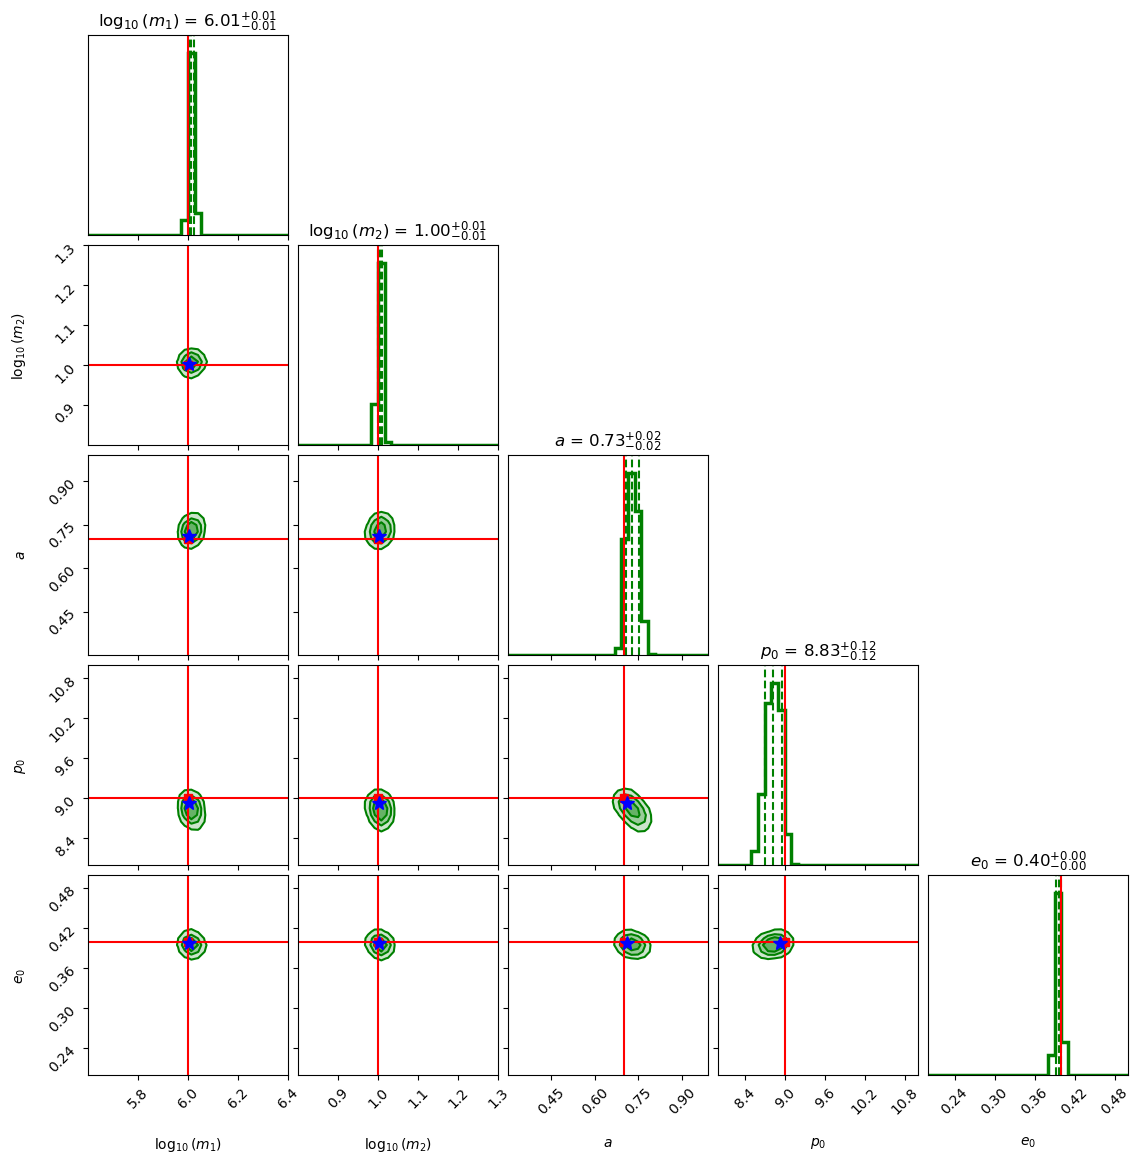

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




#  connection

In [19]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):

        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf

        log_likes[i] = loglike

    return log_likes

In [20]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.00566394, 1.00254068, 0.71180224, 8.93288898, 0.39785775]])

In [21]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [22]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [23]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [24]:
logden_theory_proc1

array([8.4430363 , 8.55782382, 8.52120172, 8.35371954, 8.04656454,
       7.58467151, 6.96796474, 6.22247839, 5.39820955, 4.55665329,
       3.75509391, 3.03544786, 2.41994965, 1.91350956, 1.50899178,
       1.19288514, 0.94965354, 0.76449434, 0.62463687, 0.51970348,
       0.44163703, 0.38442529, 0.34363045, 0.3161712 , 0.29999714,
       0.29392238, 0.29755602, 0.3112068 , 0.33594959, 0.37373909,
       0.42757401, 0.50175423, 0.60225033, 0.73706553, 0.91662294,
       1.1539477 , 1.46441496, 1.86455418, 2.36958856, 2.98893379,
       3.72045006, 4.5441012 , 5.41847258, 6.28349196, 7.07115616,
       7.7228038 , 8.20527054, 8.51787497, 8.6848473 , 8.73506883])

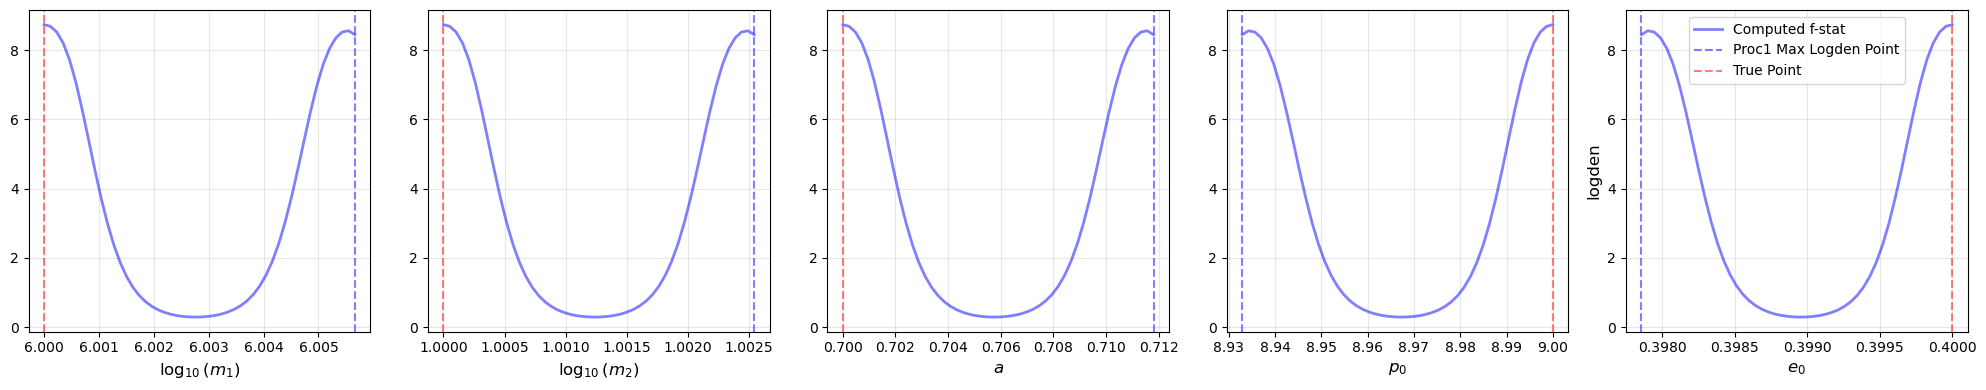

In [25]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [27]:
import GWfuncs_pure
gwf_p = GWfuncs_pure.GravWaveAnalysis(T,dt)

In [28]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf_p.Xstat(data, template)
    X_proc1_nont.append(X.get())

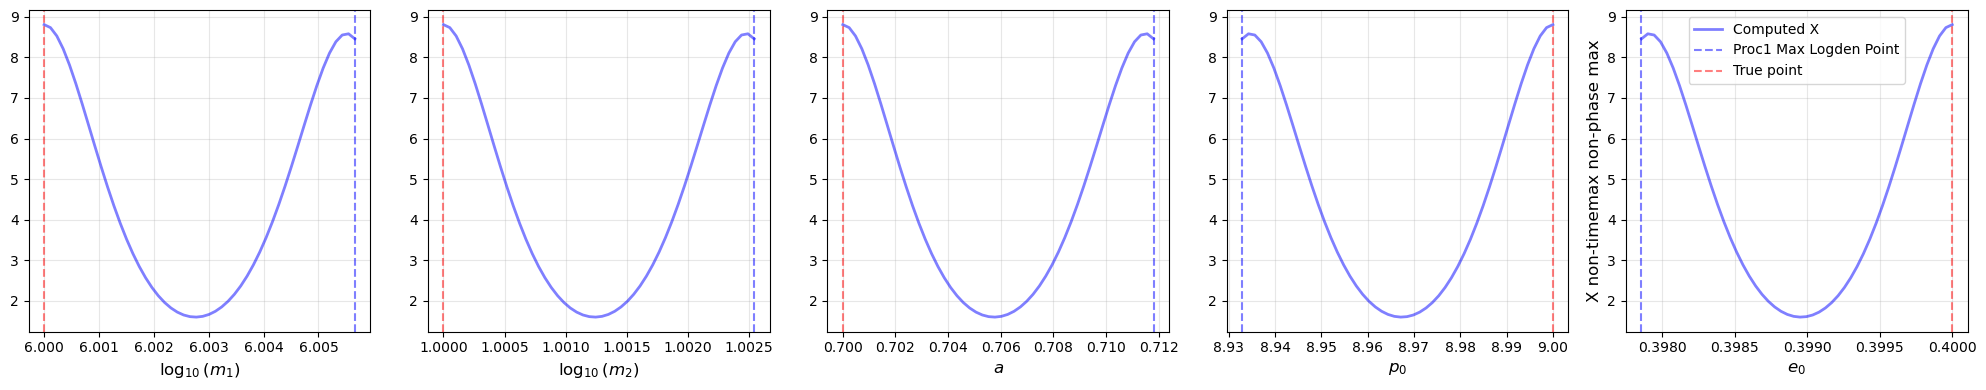

In [29]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X non-timemax non-phase max', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [30]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [31]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP 
    waveforms_per_group = []
    for group in groups:
        mode_form= waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist,
                                    qS, phiS, qK, phiK, 
                                    Phi_phi0, Phi_theta0, Phi_r0,
                                    dt=dt, T=T,
                                    mode_selection=group,  # Pass group list
                                    include_minus_mkn=False)

        # mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
        #                                   qS, phiS, qK, phiK, 
        #                                   Phi_phi0, Phi_theta0, Phi_r0,
        #                                   dt=dt, T=T,
        #                                   mode_selection=group,  # Pass group list
        #                                   include_minus_mkn=False)
        # # Sum all modes within this group
        # mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [32]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf_p.rhostat_modes(hm_arr.T))

In [33]:
rhostats_proc1[0] #sec

array([0.29064912, 0.55604798, 2.73224864, 5.63032769, 4.48931006,
       2.71226479, 1.46993668])

In [34]:
rhostats_proc1[-1] #true

array([0.28809476, 0.54073638, 2.69128056, 5.58958464, 4.48865361,
       2.73077681, 1.49016203])

In [35]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf_p.Xmstat(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [36]:
Xm_proc1[0] #sec

array([0.26261989+0.j, 0.52335302+0.j, 2.74793956+0.j, 5.78977049+0.j,
       4.56954486+0.j, 2.67171192+0.j, 1.37467343+0.j])

In [37]:
Xm_proc1[-1] #true

array([0.2962861 +0.j, 0.56303621+0.j, 2.82050196+0.j, 5.88440241+0.j,
       4.76056342+0.j, 2.91512586+0.j, 1.59954325+0.j])

In [38]:
                                        
chi2_proc1 = []                                                                                                                                                                                                          
for i in range(len(mode_forms)):                                                                                                                                                                                         
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])                                                                                                                                                                    
    chi2_proc1.append(chi2.get())    

In [40]:
chi2_proc1

[array(0.04468005),
 array(0.0756891),
 array(0.09618658),
 array(0.10294531),
 array(0.19999988),
 array(0.5391654),
 array(1.26792382),
 array(2.49337922),
 array(4.2648551),
 array(6.5716907),
 array(9.35323303),
 array(12.5125479),
 array(15.93368949),
 array(19.49509228),
 array(23.08092812),
 array(26.58812759),
 array(29.93049837),
 array(33.03912096),
 array(35.86146506),
 array(38.36011846),
 array(40.50961001),
 array(42.29212278),
 array(43.69819069),
 array(44.7211251),
 array(45.35737381),
 array(45.60525845),
 array(45.46183465),
 array(44.92605804),
 array(43.99721259),
 array(42.67554326),
 array(40.96437875),
 array(38.87221624),
 array(36.41363532),
 array(33.61318236),
 array(30.50743784),
 array(27.147863),
 array(23.60269709),
 array(19.95853657),
 array(16.31860415),
 array(12.80101811),
 array(9.53075806),
 array(6.63109196),
 array(4.20940648),
 array(2.34114251),
 array(1.05410054),
 array(0.31509349),
 array(0.02595709),
 array(0.03274329),
 array(0.15329015),

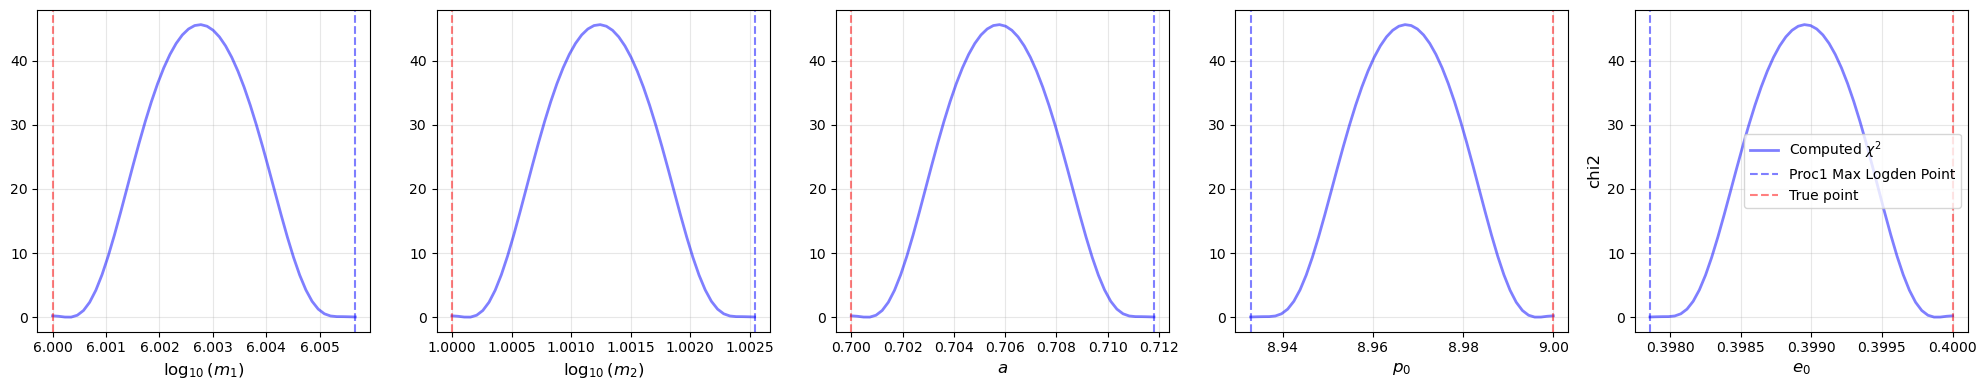

In [39]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()
